Importing the Dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import svm, metrics
import xgboost as xgb

Data Collection and Preparation

In [9]:
#loading the data into a pandas dataframe
exercise_data = pd.read_csv('/content/exercise.csv')
calories_data = pd.read_csv('/content/calories.csv')

calories_comb_data = exercise_data.merge(calories_data, on='User_ID')

In [10]:
# number of rows and columns
calories_comb_data.shape

(15000, 9)

In [11]:
# first 5 rows in the data
calories_comb_data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [13]:
# checking for missing data
calories_comb_data.isna().sum()

,0
User_ID,0
Gender,0
Age,0
Height,0
Weight,0
Duration,0
Heart_Rate,0
Body_Temp,0
Calories,0


/tmp/ipykernel_3934/1905885576.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(calories_comb_data.Calories)


<Axes: xlabel='Calories', ylabel='Density'>

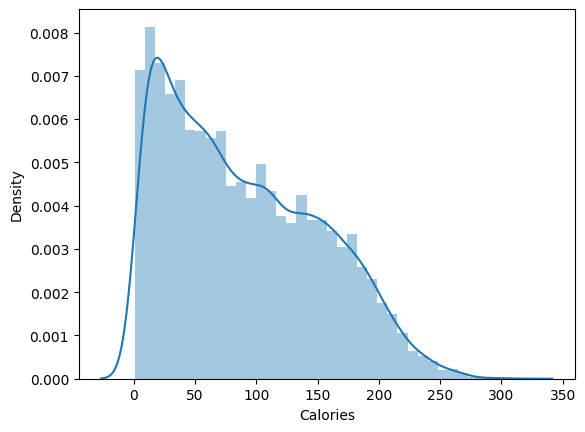

In [15]:
# checking the distribution of calories burnt
sns.distplot(calories_comb_data.Calories)

In [16]:
# converting Gender to a numerical column
calories_comb_data.Gender = calories_comb_data.Gender.astype('category').cat.codes

Separating the features and target

In [17]:
X = calories_comb_data.drop(['User_ID', 'Calories'], axis=1)
y = calories_comb_data.Calories

Splitting the data into training data and test data

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=.2, random_state=1)

Model Training

In [19]:
xgbR = xgb.XGBRegressor()
xgbR.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [20]:
metrics.r2_score(y_test, xgbR.predict(X_test))

0.9986863132331905

In [21]:
metrics.mean_absolute_error(y_test, xgbR.predict(X_test))

1.5521575984954834

In [22]:
metrics.mean_squared_error(y_test, xgbR.predict(X_test))**.5

2.2966088664340956

In [24]:
calories_comb_data.Gender.head(1)

,Gender
0,1


Building a predictive system

In [26]:
input_data=(1,68,190.0,94.0,29.0,105.0,40.8)

# converting the data into a numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshaping the data to be presented as a single record
input_array_data_reshaped =input_data_as_numpy_array.reshape(1,-1)

prediction = xgbR.predict(input_array_data_reshaped)
prediction[0]

np.float32(231.57216)